In [17]:
#Analysis_of_the_efficiency_of_interbank_transactions

import pandas as pd
import numpy as np
import io
from google.colab import files

print("Kutubxonalar tayyor!")

Kutubxonalar tayyor!


In [18]:
# 1. Kompyuterdan faylni tanlash oynasini ochish
uploaded = files.upload()

# 2. Yuklangan fayl nomini aniqlash (o'zgaruvchi nomi o'zgarmaydi)
file_name = list(uploaded.keys())[0]

# 3. Faylni Pandas orqali o'qish
try:
    # UTF-8 formatida o'qib ko'rish
    df = pd.read_csv(io.BytesIO(uploaded[file_name]), sep=None, engine='python', encoding='utf-8')
except:
    # Agar xato bersa, Excelning standart formatida o'qish
    df = pd.read_csv(io.BytesIO(uploaded[file_name]), sep=None, engine='python', encoding='cp1252')

print(f"\nTabriklayman! '{file_name}' fayli muvaffaqiyatli yuklandi.")

Saving bank_data_clean.csv to bank_data_clean (2).csv

Tabriklayman! 'bank_data_clean (2).csv' fayli muvaffaqiyatli yuklandi.


In [19]:
# 1. Jadvalni o'qish (Windows formatida)
try:
    df = pd.read_csv(io.BytesIO(uploaded[file_name]), sep=None, engine='python', encoding='cp1252', header=2)
except:
    df = pd.read_csv(io.BytesIO(uploaded[file_name]), sep=None, engine='python', encoding='utf-8', header=2)

# 2. Ustun nomlarini avtomatik tozalash (ortiqcha bo'shliqlarni yo'qotish)
df.columns = [str(c).strip() for c in df.columns]

# 3. Bizga kerakli ustunni (Bank nomi) indeks orqali topamiz
# Odatda bank nomi 2-ustunda bo'ladi (indeksi 1)
bank_col = df.columns[1]

# 4. Raqamlarni tozalash (Bank nomi ustunidan boshqa hammasini)
for col in df.columns:
    if col != bank_col and col != '№':
        df[col] = pd.to_numeric(df[col].astype(str).str.replace(r'\s+', '', regex=True).str.replace(',', '.'), errors='coerce')

# 5. Bo'sh qatorlarni o'chirish (Bank nomi ustuniga qarab)
df = df.dropna(subset=[bank_col])
df = df.fillna(0)

print(f"Tozalash yakunlandi! Bank nomi ustuni sifatida '{bank_col}' tanlandi.")
df.head()

Tozalash yakunlandi! Bank nomi ustuni sifatida 'Unnamed: 1' tanlandi.


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
0,0.0,bank nomi,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,TIF MILLIY BANKI ÀJ,736527.0,23597.0,22771.0,864.0,1458406.0,57030.0,116375.0,3144.0,1937174.0,74028.0,126449.0,4297.0
2,2.0,"""O'ZSANOATQURILISHBANKI"" ÀÒB",627779.0,21090.0,16329.0,226.0,1213358.0,52187.0,209622.0,1886.0,1415273.0,65081.0,174405.0,3132.0
3,3.0,"""ASAKABANK"" ÀJ",294706.0,9547.0,4754.0,87.0,616595.0,23371.0,76161.0,478.0,713023.0,40786.0,115274.0,1705.0
4,4.0,"""KAPITALBANK"" ÀÒB",45494.0,2560.0,3234.0,168.0,650120.0,17280.0,308319.0,1248.0,871935.0,35417.0,312932.0,2447.0


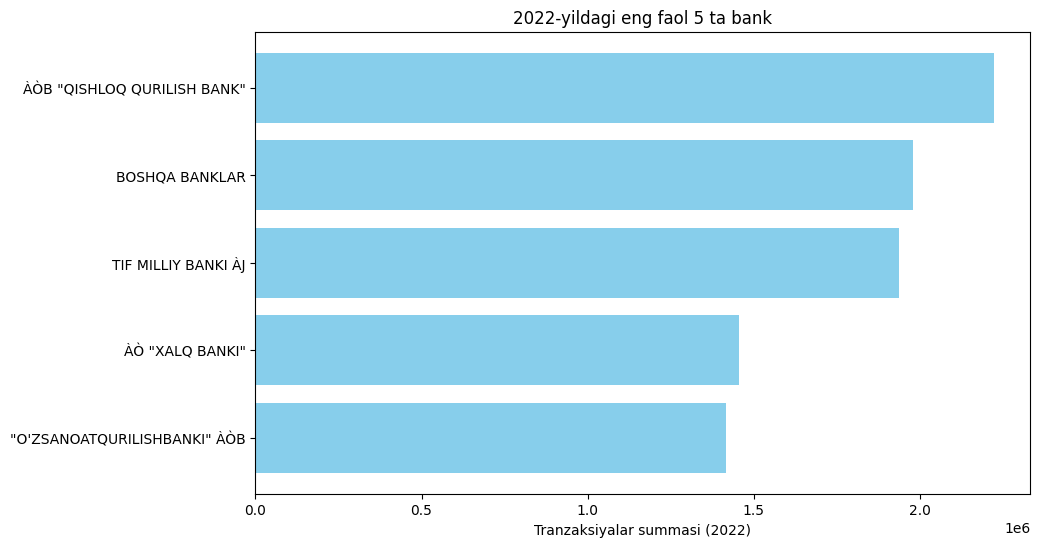

Top 5 bank ro'yxati:


,Unnamed: 1,Unnamed: 10
9,"ÀÒB ""QISHLOQ QURILISH BANK""",2222338.0
21,BOSHQA BANKLAR,1978839.0
1,TIF MILLIY BANKI ÀJ,1937174.0
8,"ÀÒ ""XALQ BANKI""",1454464.0
2,"""O'ZSANOATQURILISHBANKI"" ÀÒB",1415273.0


In [20]:
import matplotlib.pyplot as plt

# 1. 2022-yilgi summa ustunini aniqlaymiz (odatda bu jadvalning oxiridan 3-ustuni)
# Rasmga ko'ra 'Unnamed: 10' ustuni 2022_sum bo'lishi kerak
sum_2022_col = df.columns[10]
bank_col = df.columns[1]

# 2. Bank nomi 'bank nomi' deb yozilgan 0-qatorni o'chirib tashlaymiz
df_clean = df.drop(index=0)

# 3. Eng yuqori ko'rsatkichli 5 ta bankni saralab olamiz
top_5_banks = df_clean.nlargest(5, sum_2022_col)

# 4. Grafik chizish
plt.figure(figsize=(10, 6))
plt.barh(top_5_banks[bank_col], top_5_banks[sum_2022_col], color='skyblue')
plt.xlabel('Tranzaksiyalar summasi (2022)')
plt.title('2022-yildagi eng faol 5 ta bank')
plt.gca().invert_yaxis() # Eng kattasini tepaga qo'yish
plt.show()

print("Top 5 bank ro'yxati:")
display(top_5_banks[[bank_col, sum_2022_col]])

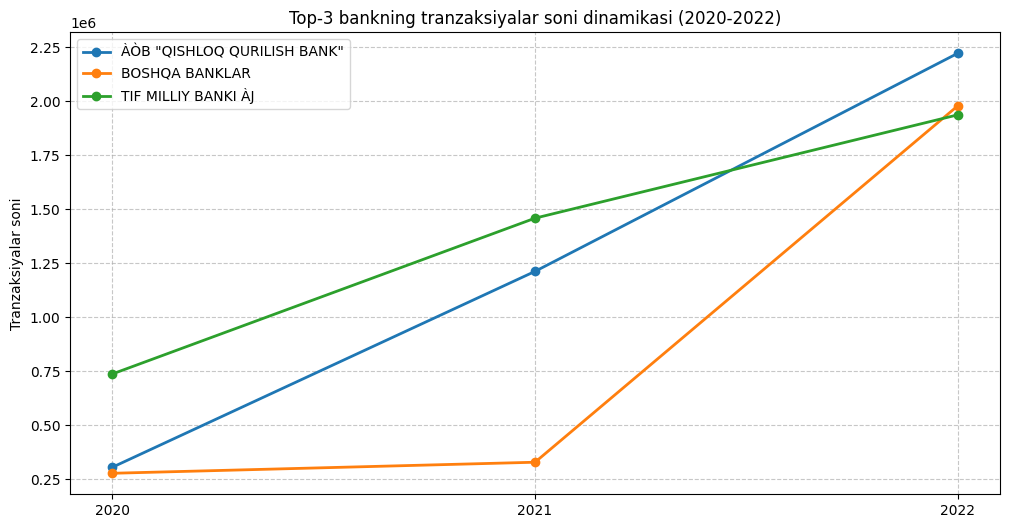

In [21]:
# 1. Ustunlarni to'g'ri tanlab olamiz (sonlar bo'yicha)
# 2020_soni (idx 2), 2021_soni (idx 6), 2022_soni (idx 10)
years = ['2020', '2021', '2022']
soni_cols = [df.columns[2], df.columns[6], df.columns[10]]
bank_col = df.columns[1]

# 2. Eng yirik 3 ta bankni tanlash (umumiy ko'rsatkich bo'yicha)
top_3_names = df_clean.nlargest(3, df.columns[10])[bank_col].values

plt.figure(figsize=(12, 6))

for bank in top_3_names:
    bank_data = df_clean[df_clean[bank_col] == bank]
    values = [bank_data[soni_cols[0]].values[0],
              bank_data[soni_cols[1]].values[0],
              bank_data[soni_cols[2]].values[0]]
    plt.plot(years, values, marker='o', label=bank, linewidth=2)

plt.title('Top-3 bankning tranzaksiyalar soni dinamikasi (2020-2022)')
plt.ylabel('Tranzaksiyalar soni')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

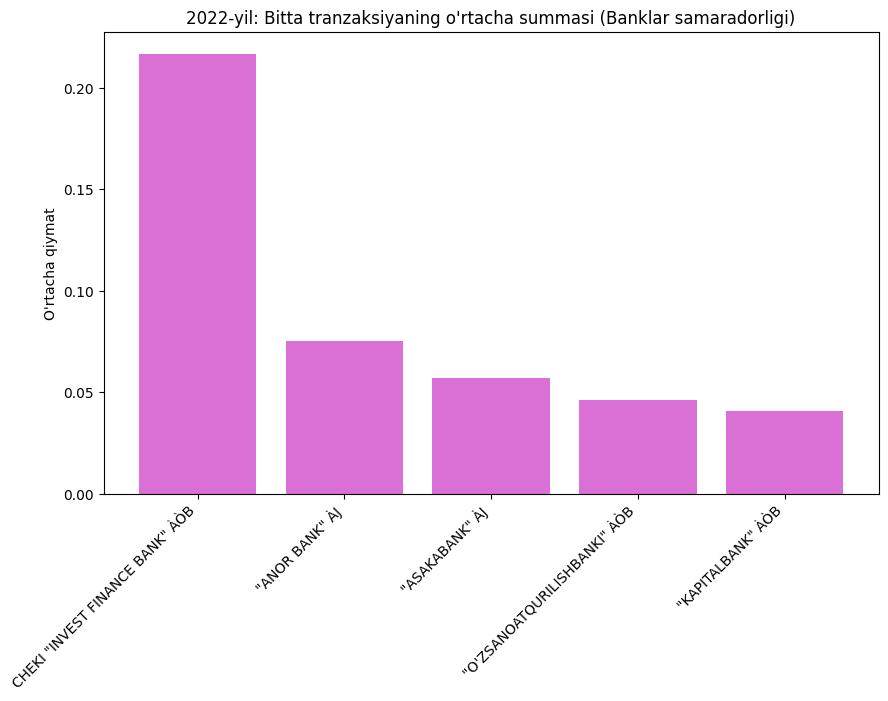

Eng yuqori 'o'rtacha chek'ka ega banklar:


,Unnamed: 1,2022_Avg_Check
18,"CHEKI ""INVEST FINANCE BANK"" ÀÒB",0.216759
19,"""ANOR BANK"" ÀJ",0.075321
3,"""ASAKABANK"" ÀJ",0.057202
2,"""O'ZSANOATQURILISHBANKI"" ÀÒB",0.045985
4,"""KAPITALBANK"" ÀÒB",0.040619


In [22]:
# 1. 2022-yil uchun bitta tranzaksiyaning o'rtacha summasini hisoblaymiz
# Formula: Summa / Soni
avg_val_col = '2022_Avg_Check'
soni_2022 = df.columns[10] # 2022_soni
summa_2022 = df.columns[11] # 2022_sum

df_clean[avg_val_col] = df_clean[summa_2022] / df_clean[soni_2022]

# 2. O'rtacha tranzaksiya qiymati bo'yicha eng yuqori top-5 bank
efficiency_top = df_clean.nlargest(5, avg_val_col)

# 3. Grafik chizish
plt.figure(figsize=(10, 6))
plt.bar(efficiency_top[bank_col], efficiency_top[avg_val_col], color='orchid')
plt.xticks(rotation=45, ha='right')
plt.title('2022-yil: Bitta tranzaksiyaning o\'rtacha summasi (Banklar samaradorligi)')
plt.ylabel('O\'rtacha qiymat')
plt.show()

print("Eng yuqori 'o'rtacha chek'ka ega banklar:")
display(efficiency_top[[bank_col, avg_val_col]])

In [24]:
# 1. Tozalangan va yangi hisob-kitoblar qo'shilgan jadvalni saqlash
output_name = 'Bank_Analysis_Result_2026.xlsx'
df_clean.to_excel(output_name, index=False)

# 2. Faylni Colab-dan kompyuteringizga yuklab olish
files.download(output_name)

print(f"Tayyor! '{output_name}' fayli kompyuteringizga yuklab olindi.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Tayyor! 'Bank_Analysis_Result_2026.xlsx' fayli kompyuteringizga yuklab olindi.
